# Section 14: FFN milestone projects

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import requests
import io

## Project 1: A gratuitously complex adding machine

In [2]:
minimum = -10
maximum = 10
X_datapoints = np.arange(minimum, maximum + 1, 2)
X_datapoints_len = len(X_datapoints)

data = np.empty((X_datapoints_len * X_datapoints_len, 3))
counter = 0

for i in X_datapoints:
    for j in X_datapoints:
        data[counter] = np.array([i, j, i + j])
        
        counter += 1
        
X = data[:, :2]
y = data[:, -1:]

X = torch.tensor(X).float()
y = torch.tensor(y).float()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [4]:
def create_adding_machine_model():
    class AddingMachineNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.input_and_output = nn.Linear(2, 1)
        
        def forward(self, x):
            return self.input_and_output(x)
    
    adding_machine_net_local = AddingMachineNet()
    loss_fun_local = nn.MSELoss()
    opt_local = torch.optim.Adam(adding_machine_net_local.parameters(), lr=.01)
    
    return adding_machine_net_local, loss_fun_local, opt_local

In [5]:
def train_model(model_param, loss_fun_param, opt_param, train_loader_param, test_loader_param):
    train_accuracies_local = []
    test_accuracies_local = []
    losses_local = []
     
    for epoch in range(50):
        batch_accuracies = []
        batch_losses = []
         
        model_param.train()
         
        for X_local, y_local in train_loader_param:
            y_pred = model_param(X_local)
            loss = loss_fun_param(y_pred, y_local)
            
            opt_param.zero_grad()
            loss.backward()
            opt_param.step()
            
            correct_predictions = torch.sum(torch.round(y_pred) == y_local).item()
            
            batch_accuracies.append(100 * correct_predictions / len(y_local))
            batch_losses.append(loss.item())
            
        train_accuracies_local.append(np.mean(batch_accuracies))
        losses_local.append(np.mean(batch_losses))
        
        model_param.eval()
        
        X_local, y_local = next(iter(test_loader_param))
        
        with torch.no_grad():
            y_pred = model_param(X_local)
        
        correct_predictions = torch.sum(torch.round(y_pred) == y_local).item()
          
        test_accuracies_local.append(100 * correct_predictions / len(y_local))
     
    return train_accuracies_local[-1], test_accuracies_local[-1], losses_local, torch.round(y_pred)

In [6]:
for i in range(10):
    adding_machine_net, loss_fun, opt = create_adding_machine_model()
    train_acc, test_acc, losses, preds = train_model(adding_machine_net, loss_fun, opt, train_loader, test_loader)
    
    print("Model instance %s, final TRAIN/TEST accuracies: %g%%, %g%%" %(i + 1, train_acc, test_acc))

Model instance 1, final TRAIN/TEST accuracies: 100%, 100%
Model instance 2, final TRAIN/TEST accuracies: 100%, 100%
Model instance 3, final TRAIN/TEST accuracies: 100%, 100%
Model instance 4, final TRAIN/TEST accuracies: 100%, 100%
Model instance 5, final TRAIN/TEST accuracies: 100%, 100%
Model instance 6, final TRAIN/TEST accuracies: 100%, 100%
Model instance 7, final TRAIN/TEST accuracies: 100%, 100%
Model instance 8, final TRAIN/TEST accuracies: 100%, 100%
Model instance 9, final TRAIN/TEST accuracies: 100%, 100%
Model instance 10, final TRAIN/TEST accuracies: 100%, 100%


In [7]:
adding_machine_net, loss_fun, opt = create_adding_machine_model()
train_acc, test_acc, losses, preds = train_model(adding_machine_net, loss_fun, opt, train_loader, test_loader)

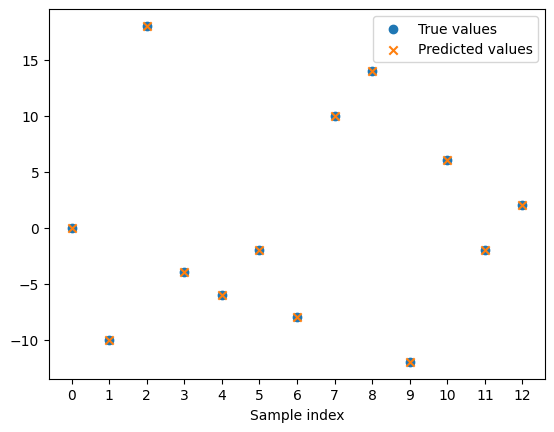

In [8]:
test_instance_indexes = range(len(preds))

plt.scatter(test_instance_indexes, y_test.flatten(), marker='o', label="True values")
plt.scatter(test_instance_indexes, preds, marker='x', label="Predicted values")
plt.xlabel("Sample index")
plt.xticks(test_instance_indexes)
plt.legend()
plt.show()

## Project 2: Predicting heart disease

In [9]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
r = requests.get(url, timeout=30)

r.raise_for_status()

names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
data = pd.read_csv(io.StringIO(r.text), sep=',', names=names)
data = data[~((data == '?').any(axis=1))]
data = data.astype(float)

X = data.drop('num', axis=1)
y = data['num']
y[y > 0] = 1.0

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.1)

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

train_dataset = TensorDataset(torch.from_numpy(X_train).float(), torch.tensor(y_train.values).float().unsqueeze(1))
test_dataset = TensorDataset(torch.from_numpy(X_test).float(), torch.tensor(y_test.values).float().unsqueeze(1))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [11]:
def create_heart_disease_model():
    class HeartDiseaseNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.input = nn.Linear(13, 16)
            self.fc1 = nn.Linear(16, 32)
            self.fc2 = nn.Linear(32, 32)
            self.output = nn.Linear(32, 1)
        
        def forward(self, x):
            x = F.relu(self.input(x))
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            
            return self.output(x)
    
    heart_disease_net_local = HeartDiseaseNet()
    loss_fun_local = nn.BCEWithLogitsLoss()
    opt_local = torch.optim.SGD(heart_disease_net_local.parameters(), lr=.01)
    
    return heart_disease_net_local, loss_fun_local, opt_local

In [12]:
def train_model(model_param, loss_fun_param, opt_param, train_loader_param, test_loader_param):
    train_accuracies_local = []
    test_accuracies_local = []
    train_losses_local = []
    test_losses_local = []
     
    for epoch in range(100):
        batch_accuracies = []
        batch_losses = []
         
        model_param.train()
         
        for X_local, y_local in train_loader_param:
            y_pred = model_param(X_local)
            train_loss = loss_fun_param(y_pred, y_local)
               
            opt_param.zero_grad()
            train_loss.backward()
            opt_param.step()
             
            correct_predictions = ((y_pred > 0) == y_local).float()
             
            batch_accuracies.append(100 * torch.mean(correct_predictions).item())
            batch_losses.append(train_loss.item())
             
        train_accuracies_local.append(np.mean(batch_accuracies))
        train_losses_local.append(np.mean(batch_losses))
    
        model_param.eval()
          
        X_local, y_local = next(iter(test_loader_param))
          
        with torch.no_grad():
            y_pred = model_param(X_local)
            test_loss = loss_fun_param(y_pred, y_local)
          
        correct_predictions = ((y_pred > 0) == y_local).float()
          
        test_accuracies_local.append(100 * torch.mean(correct_predictions).item())
        test_losses_local.append(test_loss.item())
     
    return train_accuracies_local, test_accuracies_local, train_losses_local, test_losses_local

In [13]:
heart_disease_net, loss_fun, opt = create_heart_disease_model()
train_acc, test_acc, train_loss, test_loss = train_model(heart_disease_net, loss_fun, opt, train_loader, test_loader)

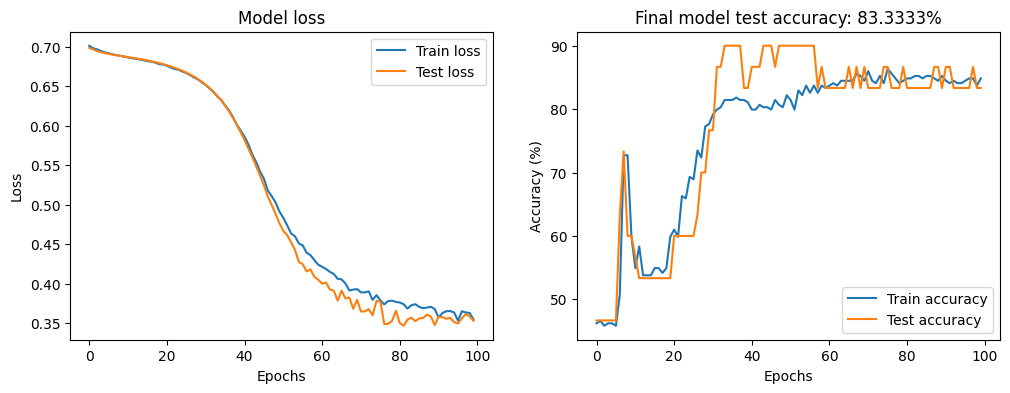

In [14]:
_, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(train_loss, label="Train loss")
ax[0].plot(test_loss, label="Test loss")
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].set_title("Model loss")

ax[1].plot(train_acc, label="Train accuracy")
ax[1].plot(test_acc, label="Test accuracy")
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].legend()
ax[1].set_title("Final model test accuracy: %g%%" %test_acc[-1])

plt.show()

## Project 3: FFN for missing data interpolation

In [15]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
r = requests.get(url, timeout=30)

r.raise_for_status()

data = pd.read_csv(io.StringIO(r.text), sep=';')
data = data.sample(frac=1)
train_data = data.iloc[10:]
test_data = data.iloc[:10]

In [16]:
scaler = MinMaxScaler()

scaler.fit(train_data)

train_data = scaler.transform(train_data)
test_data = scaler.transform(test_data)

y_train = torch.tensor(train_data[:, 3]).float().unsqueeze(-1)
X_train = torch.tensor(np.delete(train_data, [3], axis=1)).float()

y_test = torch.tensor(test_data[:, 3]).float().unsqueeze(-1)
X_test = torch.tensor(np.delete(test_data, [3], axis=1)).float()

In [17]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [18]:
def create_wine_model():
    class WineNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.input = nn.Linear(11, 32)
            self.fc1 = nn.Linear(32, 32)
            self.output = nn.Linear(32, 1)
        
        def forward(self, x):
            x = F.relu(self.input(x))
            x = F.relu(self.fc1(x))
            
            return self.output(x)
    
    wine_net_local = WineNet()
    loss_fun_local = nn.MSELoss()
    opt_local = torch.optim.Adam(wine_net_local.parameters(), lr=.001)
    
    return wine_net_local, loss_fun_local, opt_local

In [19]:
def train_model(model_param, loss_fun_param, opt_param, train_loader_param, test_loader_param):
    train_losses_local = []
    test_losses_local = []

    for epoch in range(400):
        batch_losses = []

        model_param.train()

        for X_local, y_local in train_loader_param:
            y_pred = model_param(X_local)
            loss = loss_fun_param(y_pred, y_local)

            opt_param.zero_grad()
            loss.backward()
            opt_param.step()

            batch_losses.append(loss.item())

        train_losses_local.append(np.mean(batch_losses))

        model_param.eval()

        X_local, y_local = next(iter(test_loader_param))

        with torch.no_grad():
            y_pred = model_param(X_local)

            test_losses_local.append(loss_fun_param(y_pred, y_local).item())

    return train_losses_local, test_losses_local

In [20]:
wine_net, loss_fun, opt = create_wine_model()
train_losses, test_losses = train_model(wine_net, loss_fun, opt, train_loader, test_loader)

In [21]:
wine_net.eval()

eval_train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
preds = []
obs = []

with torch.no_grad():
    for X_eval, y_eval in eval_train_loader:
        preds.append(wine_net(X_eval))
        obs.append(y_eval)

train_preds  = torch.cat(preds, 0)
y_train_true = torch.cat(obs, 0)

with torch.no_grad():
    test_preds = wine_net(X_test)

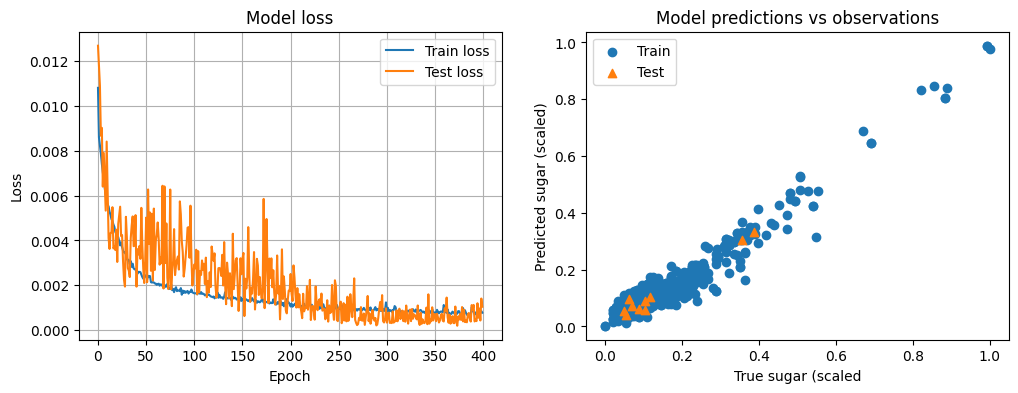

In [22]:
_, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(train_losses, label="Train loss")
ax[0].plot(test_losses, label="Test loss")
ax[0].set_title("Model loss")
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid()

ax[1].scatter(y_train_true, train_preds, marker='o', label='Train')
ax[1].scatter(y_test, test_preds, marker='^', label='Test')
ax[1].set_title("Model predictions vs observations")
ax[1].set_xlabel("True sugar (scaled")
ax[1].set_ylabel("Predicted sugar (scaled)")
ax[1].legend()

plt.show()